In [33]:
# Cell 1: Imports
import mne
import numpy as np
import matplotlib.pyplot as plt
import os
from mne.preprocessing import ICA
print(f"MNE version: {mne.__version__}")

MNE version: 1.12.1


In [34]:
# Cell 2: Load + Clean Names + Montage
data_path = r'C:\Users\Pentium\Desktop\EEG_Project\data\raw'

raw_R01 = mne.io.read_raw_edf(os.path.join(data_path, 'S003R01.edf'), preload=True, verbose=False)
raw_R02 = mne.io.read_raw_edf(os.path.join(data_path, 'S003R02.edf'), preload=True, verbose=False)

# Clean channel names
def clean_ch_names(raw):
    new_names = {ch: ch.rstrip('.').upper() for ch in raw.ch_names}
    raw.rename_channels(new_names)
    return raw

raw_R01 = clean_ch_names(raw_R01)
raw_R02 = clean_ch_names(raw_R02)

# Set montage
montage = mne.channels.make_standard_montage('standard_1005')
raw_R01.set_montage(montage, on_missing='ignore', verbose=False)
raw_R02.set_montage(montage, on_missing='ignore', verbose=False)

print(f"R01: {raw_R01.info['nchan']} channels")
print(f"R02: {raw_R02.info['nchan']} channels")
print("Montage set!")

R01: 64 channels
R02: 64 channels
Montage set!


In [35]:
# Cell 3: Preprocessing
def preprocess(raw):
    raw.set_eeg_reference('average', projection=False, verbose=False)
    raw.filter(1., 40., fir_window='hamming', verbose=False)
    raw.notch_filter(60., verbose=False)
    return raw

raw_R01 = preprocess(raw_R01)
raw_R02 = preprocess(raw_R02)
print("Preprocessing done!")

Preprocessing done!


In [36]:
# Cell 4: ICA
def run_ica(raw, n_components=20, random_state=42):
    ica = ICA(n_components=n_components, random_state=random_state, verbose=False)
    ica.fit(raw, verbose=False)
    return ica

ica_R01 = run_ica(raw_R01)
ica_R02 = run_ica(raw_R02)
print(f"R01 ICA: {ica_R01.n_components_} components")
print(f"R02 ICA: {ica_R02.n_components_} components")

R01 ICA: 20 components
R02 ICA: 20 components


In [37]:
# Cell 5: Artifact Removal
def remove_artifacts(raw, ica):
    eog_indices, _ = ica.find_bads_eog(raw, ch_name=['FP1', 'FP2'], verbose=False)
    print(f"Eye artifact components: {eog_indices}")
    ica.exclude = eog_indices
    raw_clean = raw.copy()
    ica.apply(raw_clean, verbose=False)
    return raw_clean

raw_R01_clean = remove_artifacts(raw_R01, ica_R01)
raw_R02_clean = remove_artifacts(raw_R02, ica_R02)
print("Artifact removal complete!")

Eye artifact components: [np.int64(0), np.int64(3), np.int64(2)]
Eye artifact components: []
Artifact removal complete!


In [38]:
# Cell 6: Epoching
def make_epochs(raw, duration=2.0):
    return mne.make_fixed_length_epochs(raw, duration=duration, preload=True, verbose=False)

epochs_R01 = make_epochs(raw_R01_clean)
epochs_R02 = make_epochs(raw_R02_clean)
print(f"R01: {len(epochs_R01)} epochs")
print(f"R02: {len(epochs_R02)} epochs")
print(f"Montage check: {epochs_R01.info['dig'] is not None}")

R01: 30 epochs
R02: 30 epochs
Montage check: True


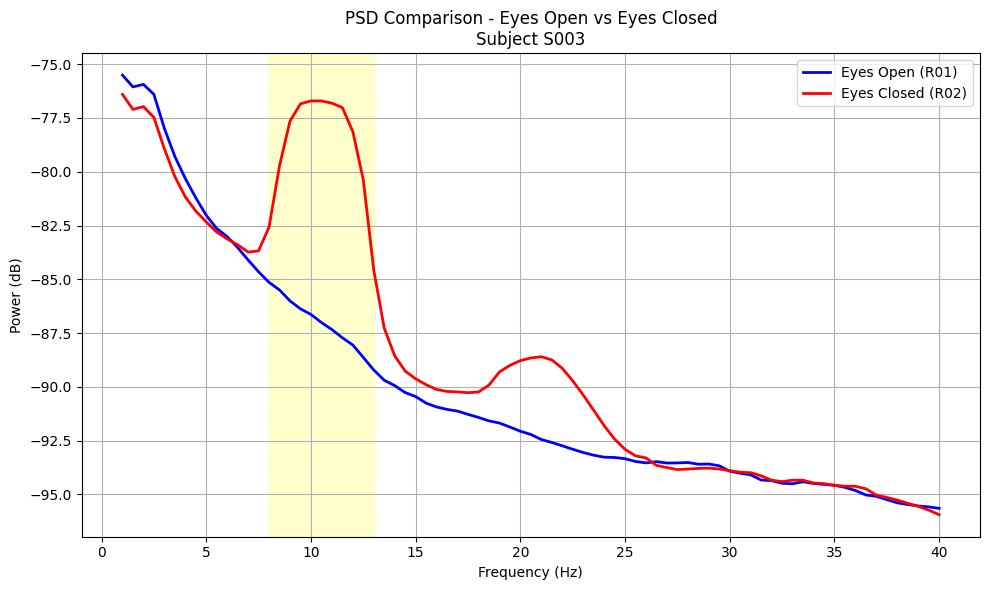

PSD saved!


In [39]:
# Cell 7: PSD Comparison
results_path = r'C:\Users\Pentium\Desktop\EEG_Project\python_mne\results\figures'
os.makedirs(results_path, exist_ok=True)

psd_R01 = epochs_R01.compute_psd(fmin=1, fmax=40, verbose=False)
psd_R02 = epochs_R02.compute_psd(fmin=1, fmax=40, verbose=False)

freqs = psd_R01.freqs
psd_R01_db = 10 * np.log10(psd_R01.get_data().mean(axis=(0, 1)))
psd_R02_db = 10 * np.log10(psd_R02.get_data().mean(axis=(0, 1)))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(freqs, psd_R01_db, 'b', linewidth=2, label='Eyes Open (R01)')
ax.plot(freqs, psd_R02_db, 'r', linewidth=2, label='Eyes Closed (R02)')
ax.axvspan(8, 13, alpha=0.2, color='yellow')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB)')
ax.set_title('PSD Comparison - Eyes Open vs Eyes Closed\nSubject S003')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'PSD_comparison_python.png'), dpi=150)
plt.show()
print("PSD saved!")

Averaging across epochs before plotting...
Averaging across epochs before plotting...


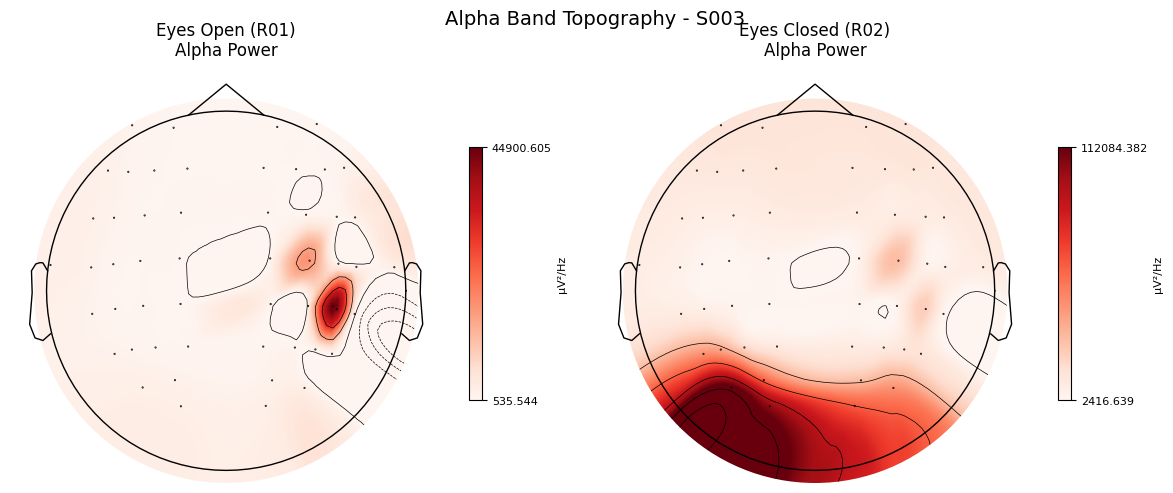

Topomap saved!


In [40]:
# Cell 8: Topographic Maps
problematic = ['FCZ', 'CZ', 'CPZ', 'FP1', 'FPZ', 'FP2', 'AFZ', 'FZ', 'PZ', 'POZ', 'OZ', 'IZ']

psd_R01_topo = psd_R01.copy().drop_channels(
    [ch for ch in problematic if ch in psd_R01.ch_names]
)
psd_R02_topo = psd_R02.copy().drop_channels(
    [ch for ch in problematic if ch in psd_R02.ch_names]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

psd_R01_topo.plot_topomap(
    bands={'Alpha (8-13 Hz)': (8, 13)}, 
    axes=axes[0], 
    show=False
)
axes[0].set_title('Eyes Open (R01)\nAlpha Power')

psd_R02_topo.plot_topomap(
    bands={'Alpha (8-13 Hz)': (8, 13)}, 
    axes=axes[1], 
    show=False
)
axes[1].set_title('Eyes Closed (R02)\nAlpha Power')

plt.suptitle('Alpha Band Topography - S003', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(results_path, 'Topomap_alpha_python.png'), dpi=150)
plt.show()
print("Topomap saved!")